# BirdCLEF 2026 Dataset - Preliminary Analysis

This notebook performs an initial exploratory analysis of the BirdCLEF 2026 data in the local `birdclef-2026/` folder.

Main goals:
- Validate available files and basic schema
- Understand label distribution and imbalance
- Inspect taxonomy and class composition
- Analyze soundscape labels and timing patterns
- Check geospatial coverage in the training metadata
- Produce practical next steps for modeling

In [21]:
import ast 
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer

import librosa
import librosa.display

from pathlib import Path
from birdclef_2026_ml.notebook_utils import init_notebook
from birdclef_2026_ml.eda import *

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
project_root = Path.cwd().parent
data_root = project_root / 'birdclef-2026'

paths = {
    # classes sounds : metadata + audio
    'train_csv': data_root / 'train.csv', 
    'train_audio_dir': data_root / 'train_audio',

    # soundscapes : metadata + audio
    'soundscape_labels_csv': data_root / 'train_soundscapes_labels.csv',
    'train_soundscapes_dir': data_root / 'train_soundscapes',
    
    # Hierarchy 
    'taxonomy_csv': data_root / 'taxonomy.csv',    
    
    # Test dataset 
    'test_soundscapes_dir': data_root / 'test_soundscapes', 
    'sample_submission_csv': data_root / 'sample_submission.csv',
}

In [4]:
train = pd.read_csv(paths['train_csv'])
taxonomy = pd.read_csv(paths['taxonomy_csv'])
soundscape_labels = pd.read_csv(paths['soundscape_labels_csv'])
sample_submission = pd.read_csv(paths['sample_submission_csv'])

print('train shape:', train.shape)
print('taxonomy shape:', taxonomy.shape)
print('soundscape_labels shape:', soundscape_labels.shape)
print('sample_submission shape:', sample_submission.shape)

display(train.head())
display(taxonomy.head())
display(soundscape_labels.head())
display(sample_submission.head())

train shape: (35549, 15)
taxonomy shape: (234, 5)
soundscape_labels shape: (1478, 4)
sample_submission shape: (3, 235)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [22]:
train_map_to_nan(train)

display(summarize_df(train))
display(summarize_df(taxonomy))
display(summarize_df(soundscape_labels))

,dtype,missing,missing_%,n_unique,avg_list_len,min_list_len,max_list_len
primary_label,str,0,0.000000,206.0,NaN,NaN,NaN
secondary_labels,object,31177,87.701482,NaN,1.699680,1.0,15.0
type,object,12975,36.498917,NaN,1.185878,1.0,7.0
latitude,float64,0,0.000000,15270.0,NaN,NaN,NaN
longitude,float64,0,0.000000,15265.0,NaN,NaN,NaN
scientific_name,str,0,0.000000,206.0,NaN,NaN,NaN
common_name,str,0,0.000000,206.0,NaN,NaN,NaN
class_name,str,0,0.000000,5.0,NaN,NaN,NaN
inat_taxon_id,int64,0,0.000000,206.0,NaN,NaN,NaN
author,str,0,0.000000,4017.0,NaN,NaN,NaN


,dtype,missing,missing_%,n_unique,avg_list_len,min_list_len,max_list_len
primary_label,str,0,0.0,234.0,NaN,NaN,NaN
inat_taxon_id,int64,0,0.0,210.0,NaN,NaN,NaN
scientific_name,str,0,0.0,234.0,NaN,NaN,NaN
common_name,str,0,0.0,234.0,NaN,NaN,NaN
class_name,str,0,0.0,5.0,NaN,NaN,NaN


,dtype,missing,missing_%,n_unique,avg_list_len,min_list_len,max_list_len
filename,str,0,0.0,66.0,NaN,NaN,NaN
start,str,0,0.0,12.0,NaN,NaN,NaN
end,str,0,0.0,12.0,NaN,NaN,NaN
primary_label,str,0,0.0,251.0,NaN,NaN,NaN
primary_label_list,object,0,0.0,NaN,4.224628,1.0,10.0


#### `train`

<Axes: xlabel='rating', ylabel='count'>

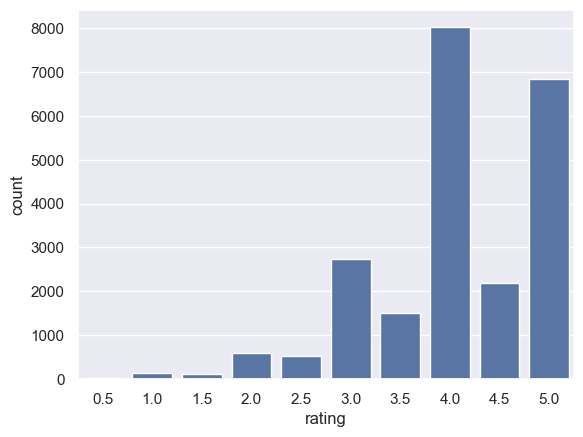

In [23]:
sns.barplot(train["rating"].value_counts())

Train rows with valid coordinates: 35549 / 35549
Latitude range: (np.float64(-54.8574), np.float64(69.578))
Longitude range: (np.float64(-159.6556), np.float64(175.3239))
Train rows with valid coordinates: 22700 / 35549
Latitude range: (np.float64(-54.8378), np.float64(69.578))
Longitude range: (np.float64(-159.6556), np.float64(175.3239))
rating range: (np.float64(0.5), np.float64(5.0))


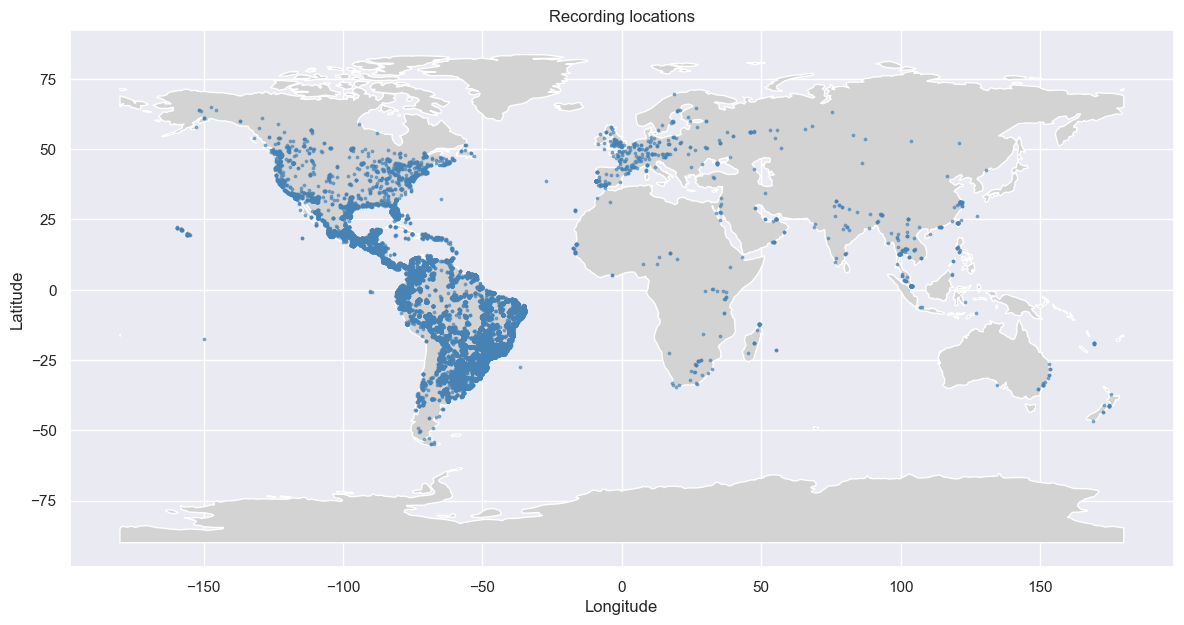

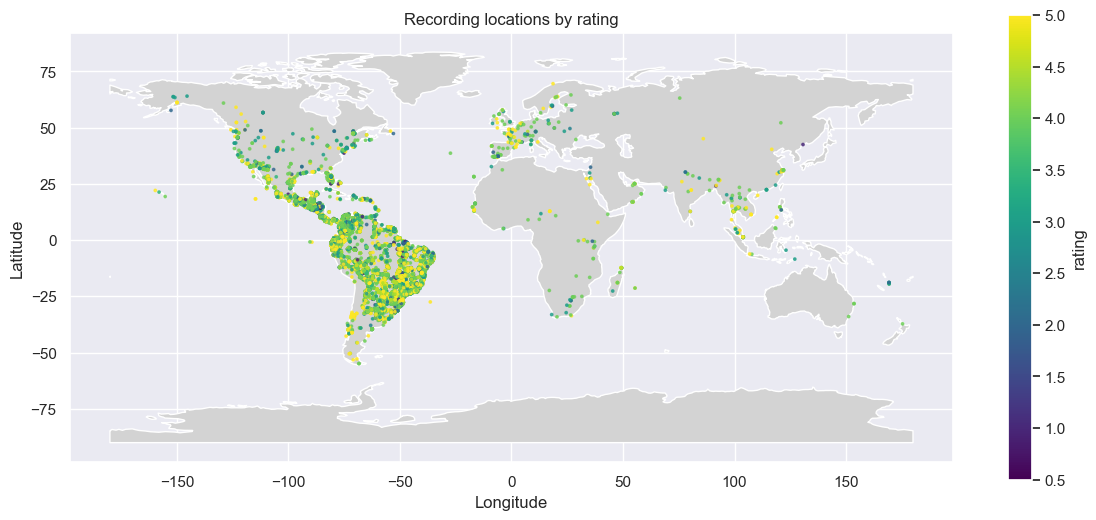

In [ ]:
plot_train_locations(train)
plot_train_locations(train, hue_col='rating')

##### `soundscape_labels`
This is what will be included in the test dataset

In [25]:
mlb = MultiLabelBinarizer() # multi-hot encoding
soundscape_labels["primary_label_list"] = soundscape_labels["primary_label"].str.split(";")
Y = mlb.fit_transform(soundscape_labels["primary_label_list"])

Train rows with valid coordinates: 6540 / 6540
Latitude range: (np.float64(-39.6743), np.float64(59.9674))
Longitude range: (np.float64(-159.6556), np.float64(169.2891))


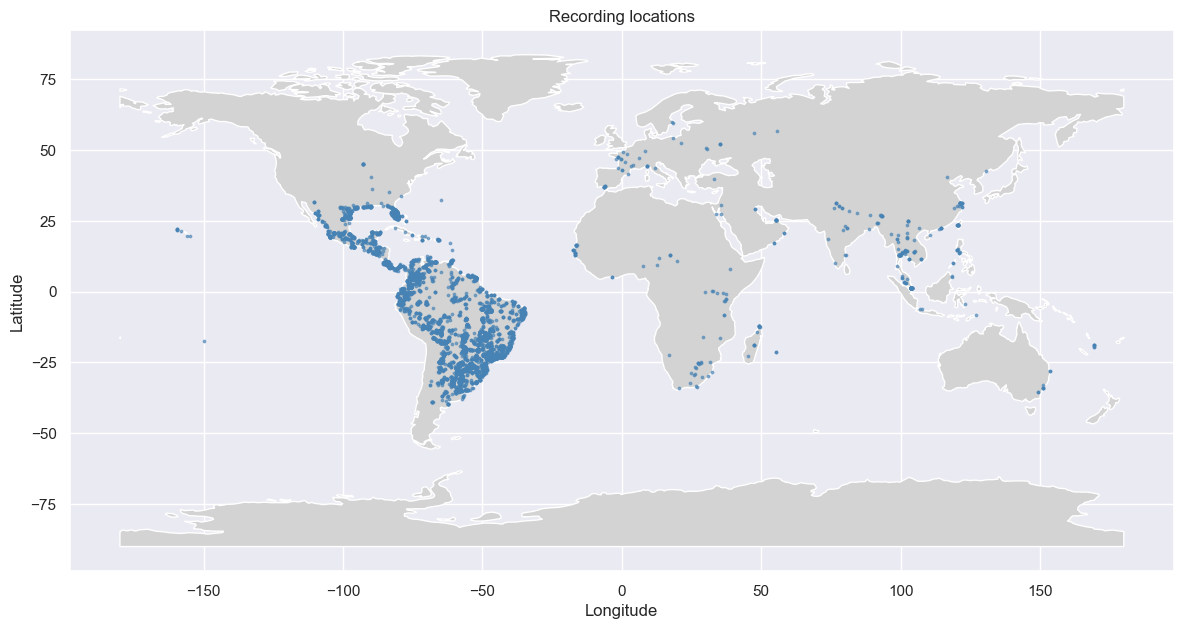

In [26]:
# Locations present in train_soundscapes
train_sl = train[train["primary_label"].isin(soundscape_labels["primary_label_list"].explode())]
plot_train_locations(train_sl)

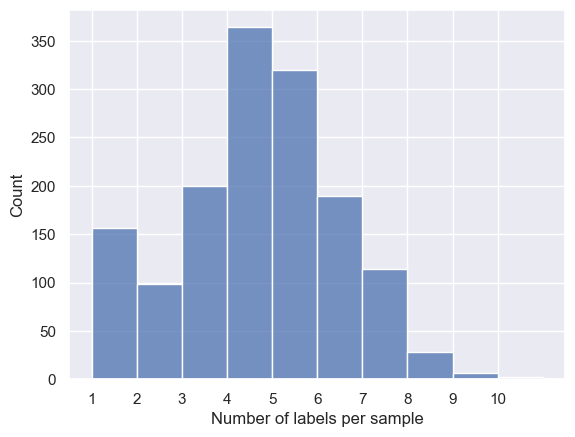

In [27]:
counts = Y.sum(axis=1)
mn, mx = counts.min(), counts.max()
bins = np.arange(mn, mx + 2) 
sns.histplot(counts, bins=bins)
plt.xticks(np.arange(mn, mx + 1)) 
plt.xlabel("Number of labels per sample")
plt.ylabel("Count")
plt.show()

Number of classes in soundscapes: 75
Number of classes in train: 206


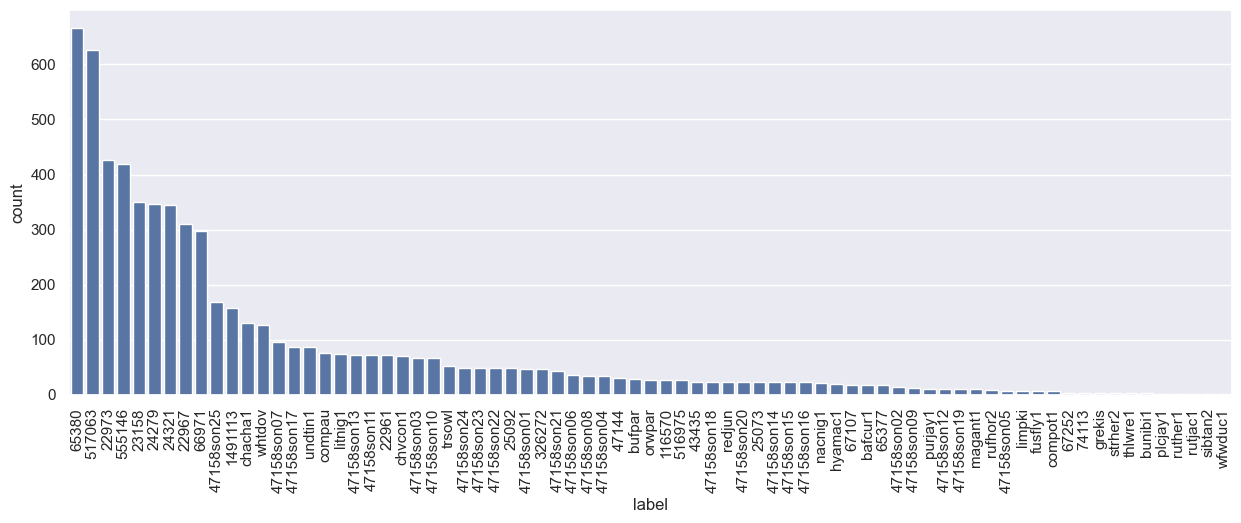

In [28]:
print("Number of classes in soundscapes:", len(mlb.classes_))
print("Number of classes in train:",  train["primary_label"].nunique())

# How much each class appears
df = pd.DataFrame(data={"label":mlb.classes_, "count":Y.sum(axis=0)}).sort_values("count", ascending=False)
plt.figure(figsize=(15, 5))
sns.barplot(data=df, x="label", y="count")
plt.xticks(rotation=90);

<Axes: >

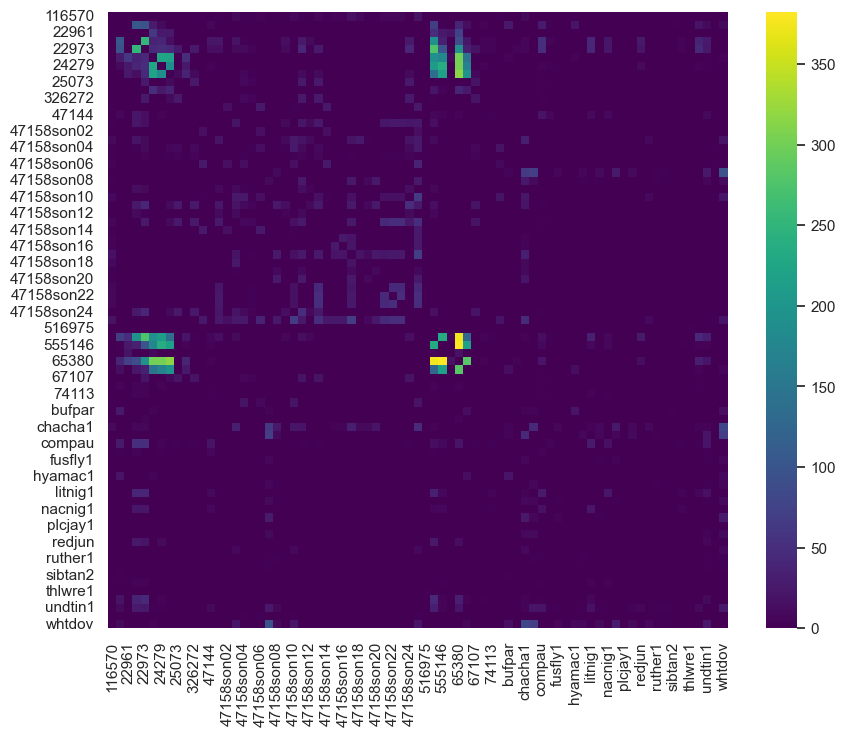

In [29]:
# Cooccurence matrix
C = Y.T @ Y
np.fill_diagonal(C, val=0)
df = pd.DataFrame(data=C, index=mlb.classes_, columns=mlb.classes_)
fig=plt.figure(figsize=(10, 8))
sns.heatmap(data=df, cmap="viridis")

<Axes: >

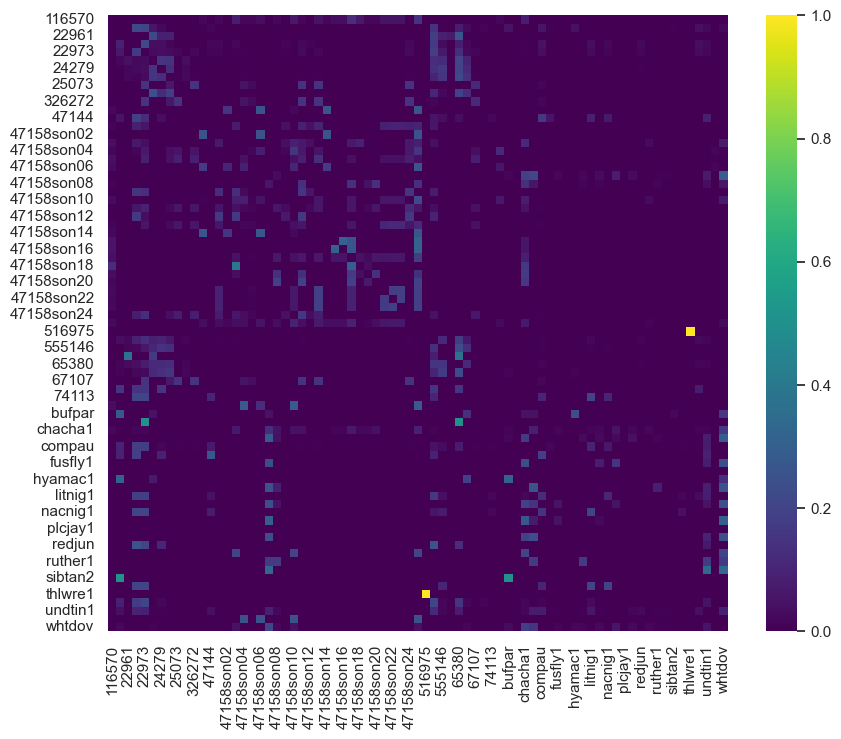

In [30]:
# Cooccurence matrix, normalized per row -> should be read per row and interpreted as a probability distribution
C = Y.T @ Y
np.fill_diagonal(C, val=0)
D = C.sum(axis=1).reshape(-1, 1)
C_normalized = np.divide(C, D, where=D != 0, out=np.zeros_like(C, dtype=float))

df = pd.DataFrame(data=C_normalized, index=mlb.classes_, columns=mlb.classes_)
fig=plt.figure(figsize=(10, 8))
sns.heatmap(data=df, cmap="viridis")

#### `taxonomy`

In [31]:
fig = px.sunburst(
    taxonomy,
    path=["class_name", "common_name"],  # hierarchy
    values=None  # counts automatically
)

fig.show()

#### `train_audio_dir`

In [ ]:
# def get_duration(path):
#     print(path)
#     y, sr = librosa.load(paths["train_audio_dir"] / path, sr=None)
#     return len(y) / sr

# train["duration"] = train["filename"].apply(get_duration)

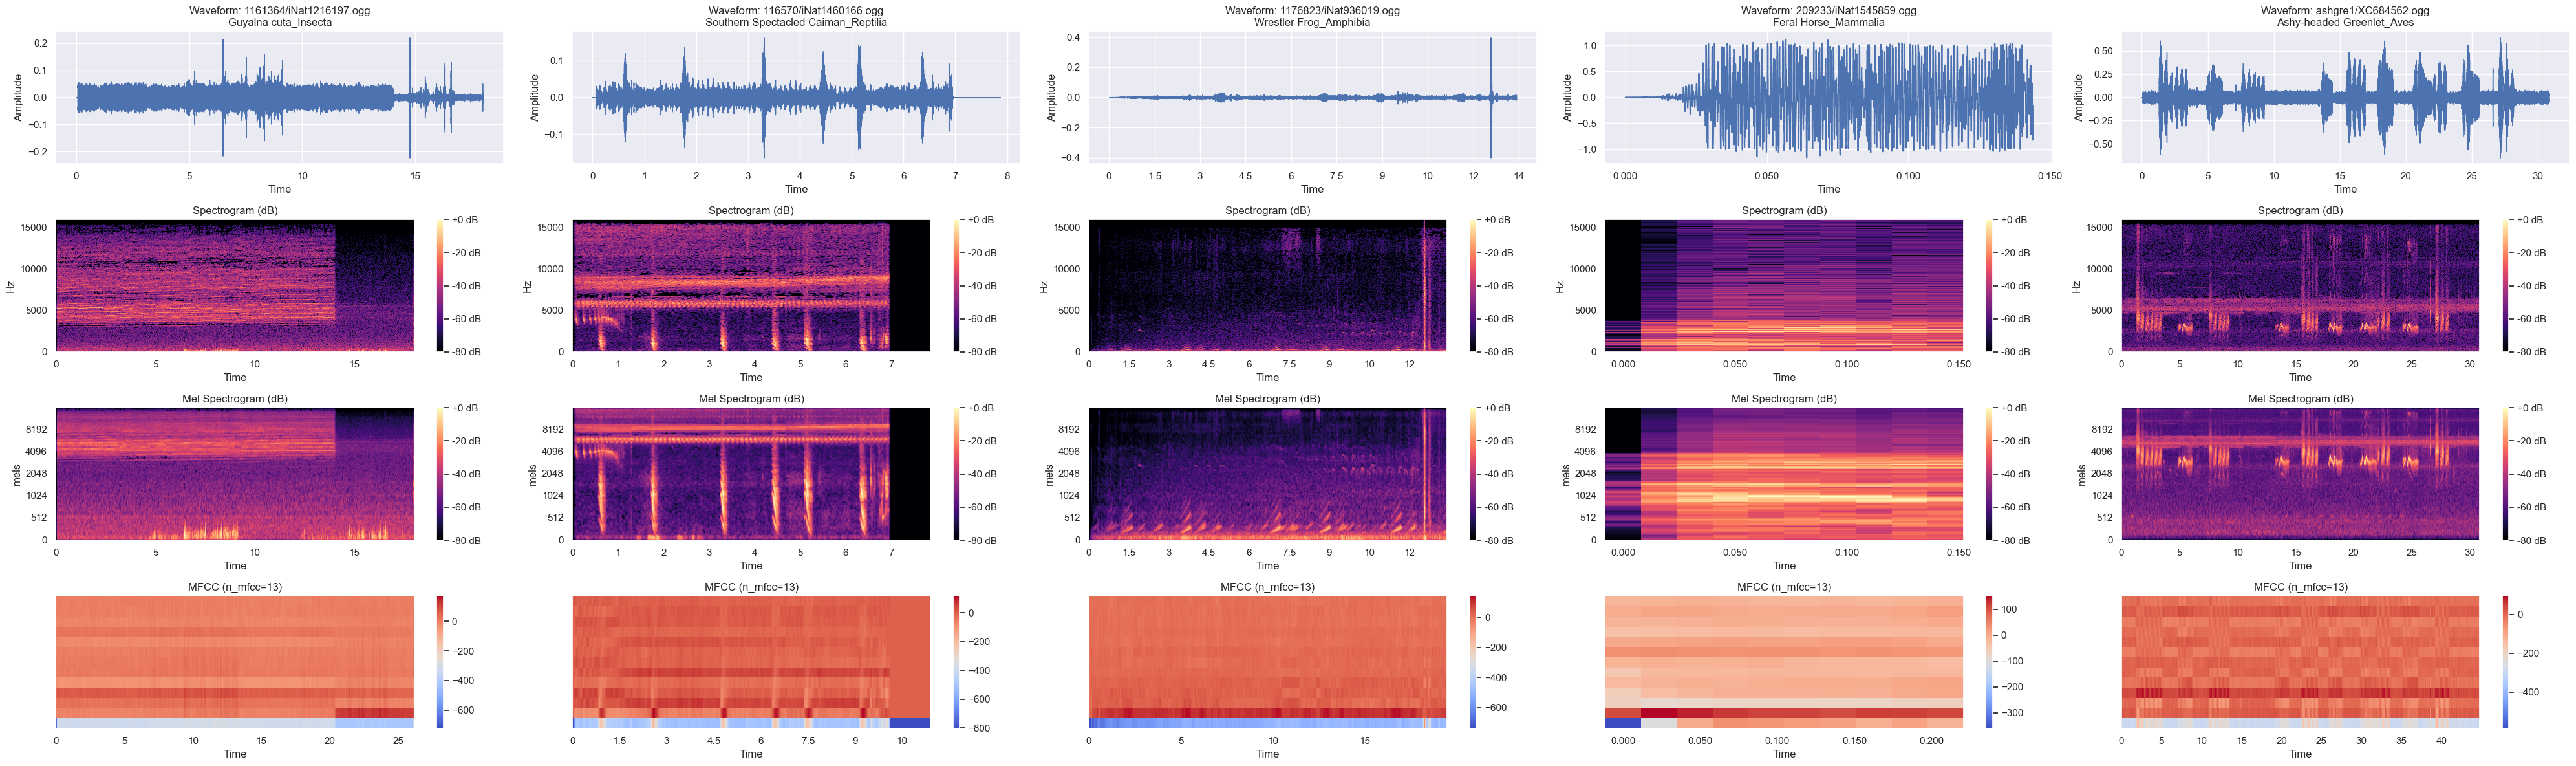

In [57]:
# By class_name
train_slice = train.groupby('class_name', sort=False, as_index=False).first()

n_cols = len(train_slice)
example_paths = train_slice['filename'].tolist()
extra_titles = (train_slice['common_name'].astype(str) + '_' + train_slice['class_name'].astype(str)).tolist()

plot_audio_overview_grid(example_paths, paths['train_audio_dir'], n_cols=n_cols, extra_titles=extra_titles)

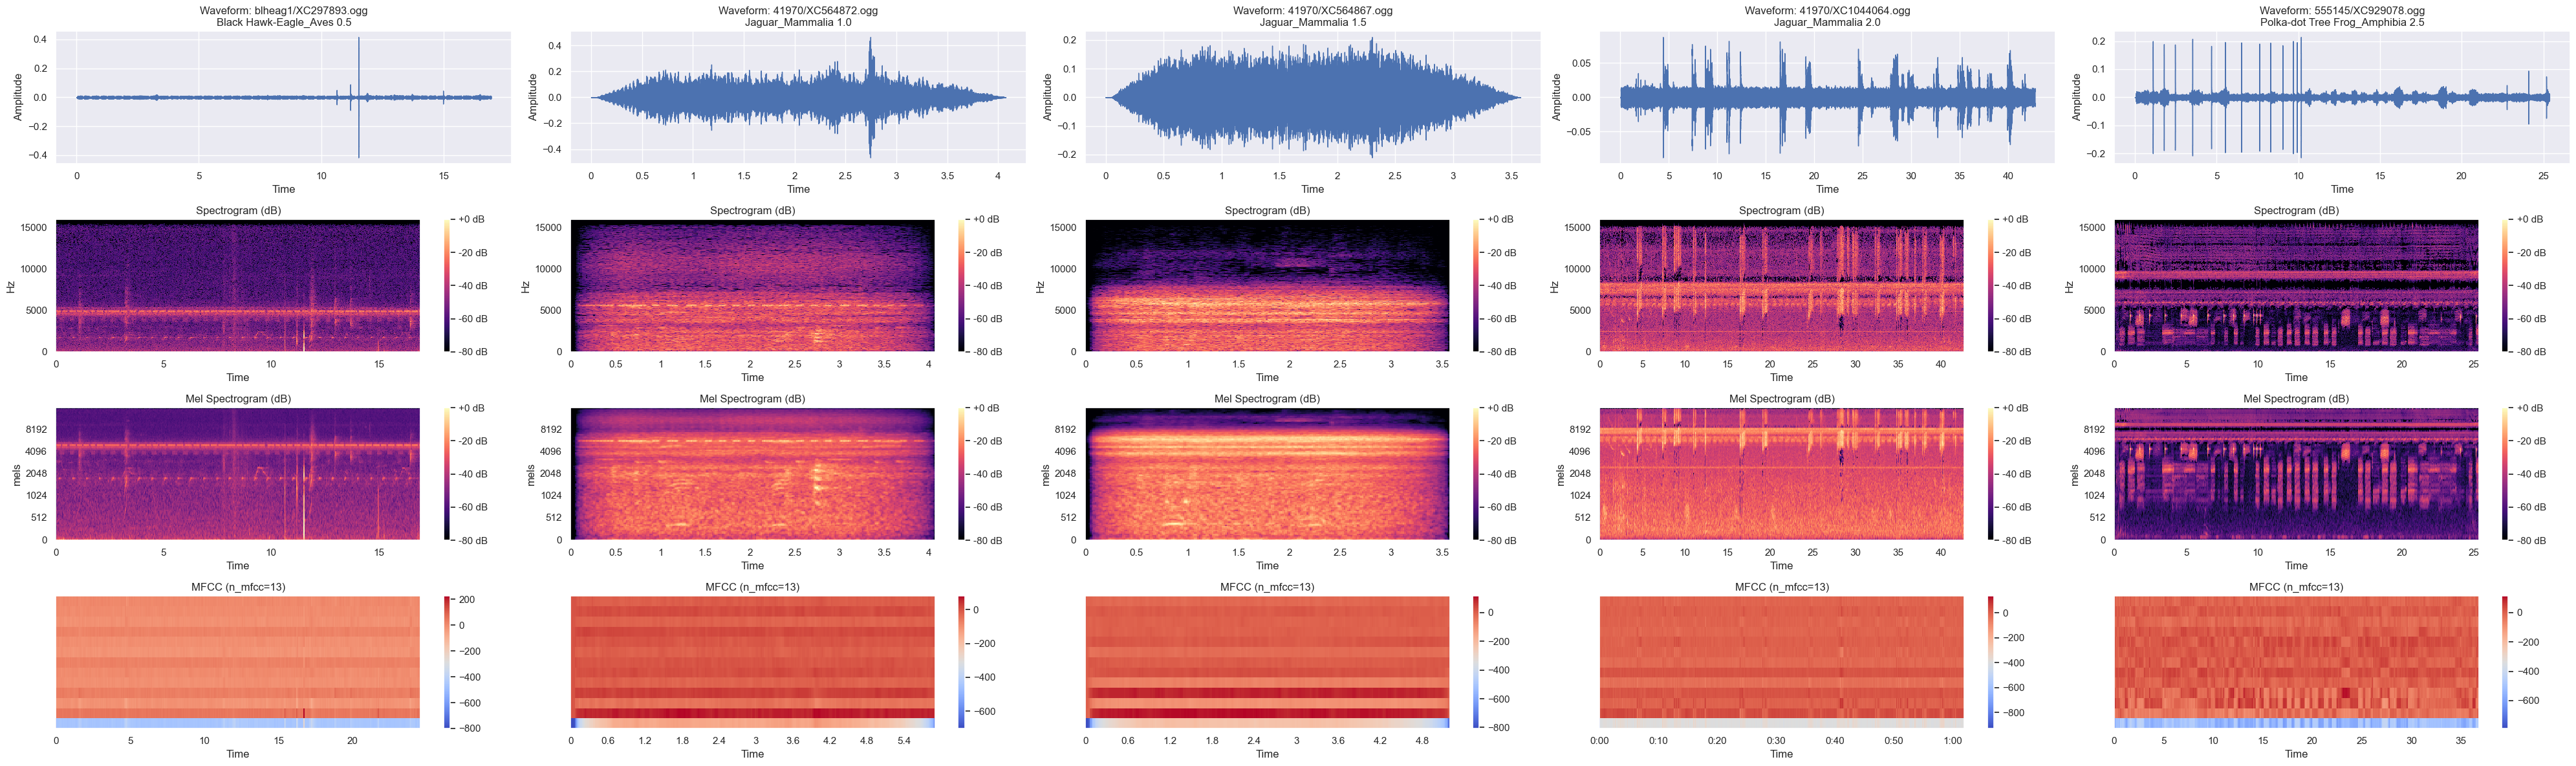

In [ ]:
# By rating (worst)
train_slice = train.groupby('rating', sort=True, as_index=False).first().head(5)

example_paths = train_slice['filename'].tolist()
extra_titles = (train_slice['common_name'].astype(str) + '_'
                + train_slice['class_name'].astype(str) + ' '
                + train_slice['rating'].astype(str)).tolist()

plot_audio_overview_grid(example_paths, paths['train_audio_dir'], n_cols=5, extra_titles=extra_titles)

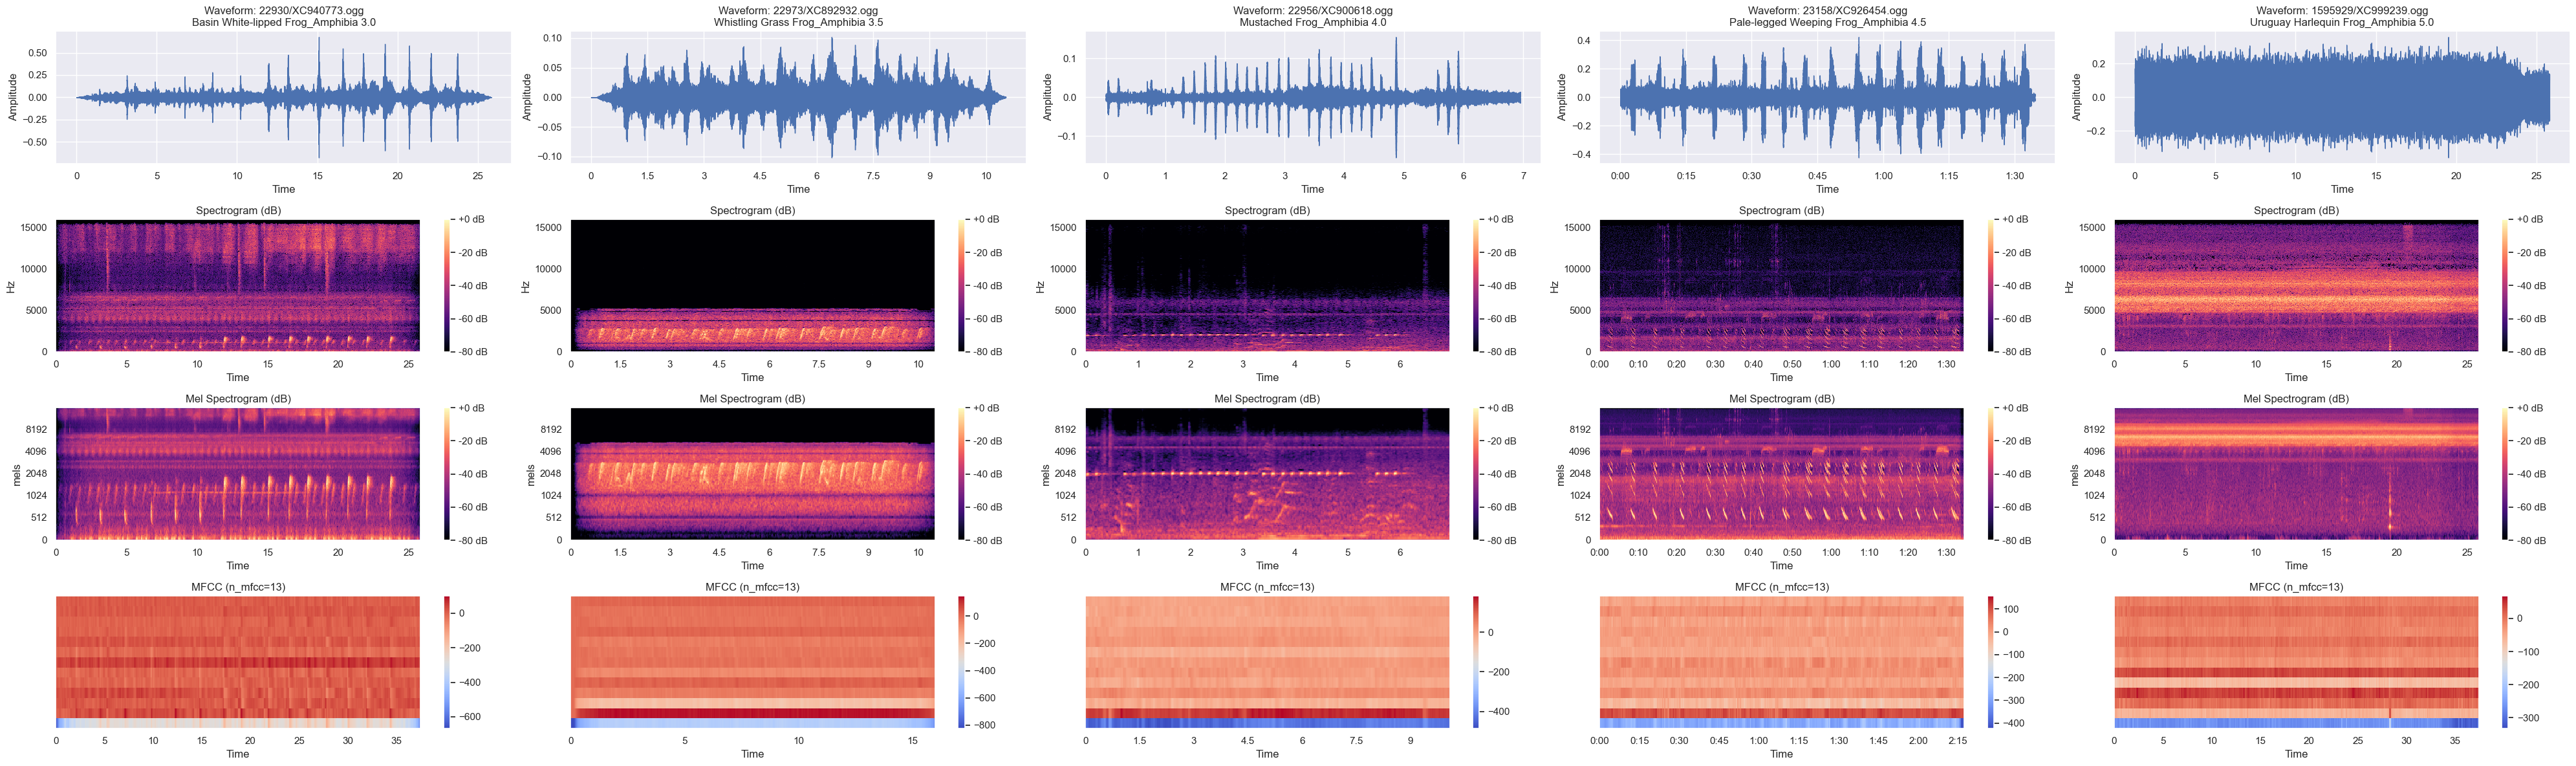

In [ ]:
# By rating (best)

train_slice = train.groupby('rating', sort=True, as_index=False).first().tail(5)

example_paths = train_slice['filename'].tolist()
extra_titles = (train_slice['common_name'].astype(str) + '_'
                + train_slice['class_name'].astype(str) + ' '
                + train_slice['rating'].astype(str)).tolist()

plot_audio_overview_grid(example_paths, paths['train_audio_dir'], n_cols=5, extra_titles=extra_titles)

***

In [ ]:
def parse_secondary_labels(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text in {'', '[]'}:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    # Fallback for unexpected delimiter formatting
    cleaned = text.strip('[]')
    if not cleaned:
        return []
    return [x.strip().strip("'").strip('\"') for x in cleaned.split(',') if x.strip()]

secondary_series = train['secondary_labels'].apply(parse_secondary_labels)
secondary_exploded = secondary_series.explode().dropna()

print('Rows with at least one secondary label:', int((secondary_series.str.len() > 0).sum()))
print('Unique secondary labels:', secondary_exploded.nunique())

secondary_exploded.value_counts().head(15).to_frame('count')

In [ ]:
# Compare metadata counts with physically present audio files per label directory
audio_dir = paths['train_audio_dir']
folder_counts = {}
if audio_dir.exists():
    for d in audio_dir.iterdir():
        if d.is_dir():
            folder_counts[d.name] = len(list(d.glob('*.ogg')))

audio_counts = (
    pd.Series(folder_counts, name='files_in_folder')
    .rename_axis('primary_label')
    .reset_index()
)

metadata_counts = train['primary_label'].value_counts().rename_axis('primary_label').reset_index(name='rows_in_train_csv')
coverage = metadata_counts.merge(audio_counts, on='primary_label', how='outer').fillna(0)
coverage[['rows_in_train_csv', 'files_in_folder']] = coverage[['rows_in_train_csv', 'files_in_folder']].astype(int)
coverage['difference'] = coverage['rows_in_train_csv'] - coverage['files_in_folder']

print('Total train rows:', int(coverage['rows_in_train_csv'].sum()))
print('Total audio files found:', int(coverage['files_in_folder'].sum()))
print('Labels with mismatch:', int((coverage['difference'] != 0).sum()))

coverage.sort_values('difference', key=np.abs, ascending=False).head(20)

In [ ]:
# Parse timestamp from soundscape filename pattern: *_YYYYMMDD_HHMMSS.ogg
def extract_datetime_from_soundscape_filename(filename):
    match = re.search(r'_(\\d{8})_(\\d{6})\\.ogg$', str(filename))
    if not match:
        return pd.NaT
    dt_str = f"{match.group(1)} {match.group(2)}"
    return pd.to_datetime(dt_str, format='%Y%m%d %H%M%S', errors='coerce')

soundscape_time = soundscape_labels.copy()
soundscape_time['datetime'] = soundscape_time['filename'].apply(extract_datetime_from_soundscape_filename)
soundscape_time['hour'] = soundscape_time['datetime'].dt.hour

valid_hours = soundscape_time['hour'].dropna().astype(int)
print('Rows with parsed datetime:', len(valid_hours), '/', len(soundscape_time))

if len(valid_hours) > 0:
    plt.figure(figsize=(10, 4))
    valid_hours.value_counts().sort_index().plot(kind='bar', color='darkslateblue')
    plt.title('Soundscape segment count by hour of day')
    plt.xlabel('Hour')
    plt.ylabel('Segments')
    plt.tight_layout()
    plt.show()
else:
    print('No parseable timestamps found in soundscape filenames.')

In [ ]:
submission_label_cols = [c for c in sample_submission.columns if c != 'row_id']
taxonomy_labels = set(taxonomy['primary_label'].astype(str))
submission_labels = set(map(str, submission_label_cols))

print('Submission rows:', len(sample_submission))
print('Submission label columns:', len(submission_label_cols))
print('Labels in submission but not taxonomy:', len(submission_labels - taxonomy_labels))
print('Labels in taxonomy but not submission:', len(taxonomy_labels - submission_labels))

sample_submission.iloc[:3, :12]